In [15]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [46]:
import subprocess, sys
subprocess.check_call([sys.executable, "-m", "pip", "install",
                        "wordcloud", "gensim", "gradio", "-q"])

0

# Section III - NLP Classification Tasks
## Headline Category Prediction with Recurrent Neural Networks

Source file: news_category.csv (fields: headline, category)  
Objective: classify each news headline into its category using three RNN-based architectures

## Library Imports and Environment Setup

In [17]:
import os
import re
import json
import time
import warnings
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

from wordcloud import WordCloud

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.utils.class_weight import compute_class_weight

import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Embedding, SimpleRNN, LSTM, Dense, Dropout,
    Bidirectional, BatchNormalization
)
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau

from gensim.models import Word2Vec

warnings.filterwarnings('ignore')
print('Packages loaded without errors.')

Packages loaded without errors.


In [18]:
nltk.download('stopwords', quiet=True)
nltk.download('wordnet', quiet=True)
nltk.download('omw-1.4', quiet=True)
print('NLTK data assets downloaded and ready.')

NLTK data assets downloaded and ready.


In [19]:
gpu_list = tf.config.list_physical_devices('GPU')
if gpu_list:
    try:
        for dev in gpu_list:
            tf.config.experimental.set_memory_growth(dev, True)
        print('Dynamic memory growth activated')
    except RuntimeError as err:
        print(err)

print('GPU Available:', len(gpu_list) > 0)
print('GPU Devices :', gpu_list)

Dynamic memory growth activated
GPU Available: True
GPU Devices : [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [20]:
import os

target_dir = os.path.join(os.getcwd(), 'assessment-2')
if os.path.isdir(target_dir):
    os.chdir(target_dir)
elif os.path.basename(os.getcwd()) != 'assessment-2':
    # search current directory and one level up for the data file
    for search_path in [os.getcwd(),
                        os.path.join(os.getcwd(), '..', 'assessment-2')]:
        if os.path.exists(os.path.join(search_path, 'data', 'news_category.csv')):
            os.chdir(search_path)
            break

print('Working directory:', os.getcwd())
assert os.path.exists('/content/drive/MyDrive/Machine_Learning/Dataset/news_category.csv'), \
    f'Still cannot find data file in {os.getcwd()}'

Working directory: /content


# Part 1 - Text Preprocessing, Tokenization and Padding

## Reading the Dataset

In [21]:
news_df = pd.read_csv('/content/drive/MyDrive/Machine_Learning/Dataset/news_category.csv')
print(f'Dimensions : {news_df.shape}')
print(f'Columns    : {news_df.columns.tolist()}')
news_df.head(10)

Dimensions : (11025, 2)
Columns    : ['headline', 'category']


,headline,category
0,How A New Documentary Captures The Complexity ...,CULTURE & ARTS
1,Twitch Bans Gambling Sites After Streamer Scam...,TECH
2,'Reboot' Is A Clever And Not Too Navel-Gazey L...,CULTURE & ARTS
3,"Maury Wills, Base-Stealing Shortstop For Dodge...",SPORTS
4,"Las Vegas Aces Win First WNBA Title, Chelsea G...",SPORTS
5,"Meet Alex Aster, The TikToker Changing The Pub...",CULTURE & ARTS
6,TikTok Search Results Riddled With Misinformat...,TECH
7,Boston Marathon To Make Race More Inclusive Fo...,SPORTS
8,"Anthony Varvaro, MLB Pitcher Turned Transit Co...",SPORTS
9,How Ani Liu Is Brilliantly Disguising Her Art ...,CULTURE & ARTS


### Dataset Summary

In [22]:
print('Column Data Types:')
print(news_df.dtypes)
print('\nMissing Values per Column:')
print(news_df.isnull().sum())
print(f'\nTotal Records: {len(news_df):,}')

Column Data Types:
headline    object
category    object
dtype: object

Missing Values per Column:
headline    0
category    0
dtype: int64

Total Records: 11,025


Class Frequency Breakdown:
category
SPORTS            5077
TECH              2104
MONEY             1756
CULTURE & ARTS    1074
EDUCATION         1014
Name: count, dtype: int64


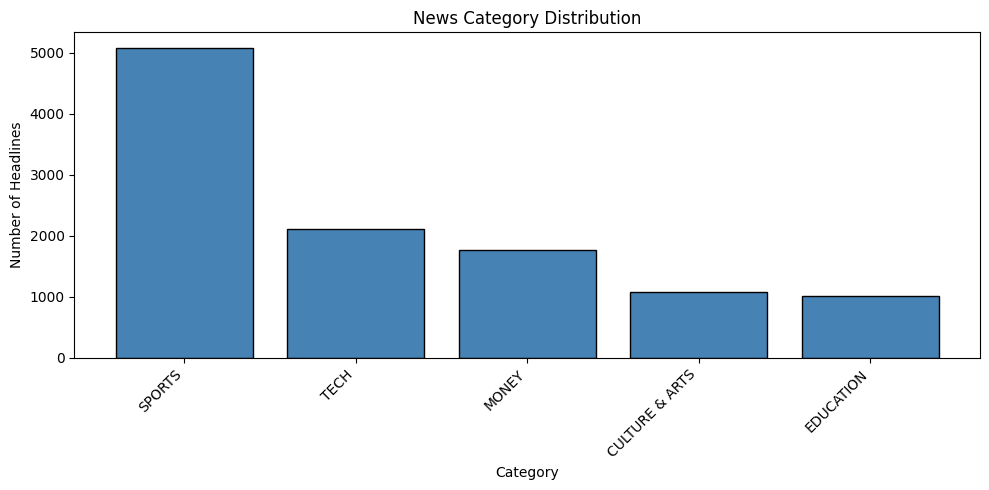

In [23]:
print('Class Frequency Breakdown:')
print(news_df['category'].value_counts())

label_counts = news_df['category'].value_counts()
plt.figure(figsize=(10, 5))
plt.bar(label_counts.index, label_counts.values, color='steelblue', edgecolor='black')
plt.xticks(rotation=45, ha='right')
plt.title('News Category Distribution')
plt.xlabel('Category')
plt.ylabel('Number of Headlines')
plt.tight_layout()
plt.show()

## Text Preprocessing Pipeline

Each headline is processed through the following steps before tokenization:
1. Convert all characters to lowercase
2. Resolve contractions (e.g. don't -> do not)
3. Remove URLs, @mentions, #hashtags, and numeric tokens
4. Filter out common stopwords
5. Apply lemmatization to reduce words to their root form

In [24]:
CONTRACTION_MAP = {
    "don't": 'do not',    "doesn't": 'does not',  "didn't": 'did not',
    "won't": 'will not',  "can't": 'cannot',       "couldn't": 'could not',
    "shouldn't": 'should not', "wouldn't": 'would not', "isn't": 'is not',
    "aren't": 'are not',  "wasn't": 'was not',     "weren't": 'were not',
    "i'm": 'i am',        "i've": 'i have',        "i'll": 'i will',
    "i'd": 'i would',     "you're": 'you are',     "you've": 'you have',
    "you'll": 'you will', "he's": 'he is',         "she's": 'she is',
    "it's": 'it is',      "we're": 'we are',       "they're": 'they are',
    "they've": 'they have', "they'll": 'they will', "that's": 'that is',
    "there's": 'there is', "here's": 'here is',    "let's": 'let us',
    "what's": 'what is',  "who's": 'who is',       "n't": ' not'
}

word_lemmatizer = WordNetLemmatizer()
english_stopwords = set(stopwords.words('english'))


def resolve_contractions(text):
    for short_form, long_form in CONTRACTION_MAP.items():
        text = text.replace(short_form, long_form)
    return text


def clean_text(text):
    text = str(text).lower()
    text = resolve_contractions(text)
    text = re.sub(r'http\S+|www\S+', '', text)
    text = re.sub(r'@\w+', '', text)
    text = re.sub(r'#\w+', '', text)
    text = re.sub(r'\d+', '', text)
    text = re.sub(r'[^\w\s]', '', text)
    tokens = text.split()
    tokens = [
        word_lemmatizer.lemmatize(w)
        for w in tokens
        if w not in english_stopwords and len(w) > 1
    ]
    return ' '.join(tokens)


news_df['cleaned_headline'] = news_df['headline'].apply(clean_text)
print('Preprocessing preview (first 5 headlines):')
for idx in range(5):
    print(f'\nRaw      : {news_df["headline"].iloc[idx]}')
    print(f'Processed: {news_df["cleaned_headline"].iloc[idx]}')

Preprocessing preview (first 5 headlines):

Raw      : How A New Documentary Captures The Complexity Of Being A Child Of Immigrants
Processed: new documentary capture complexity child immigrant

Raw      : Twitch Bans Gambling Sites After Streamer Scams Folks Out Of $200,000
Processed: twitch ban gambling site streamer scam folk

Raw      : 'Reboot' Is A Clever And Not Too Navel-Gazey Look Inside TV Reboots
Processed: reboot clever navelgazey look inside tv reboots

Raw      : Maury Wills, Base-Stealing Shortstop For Dodgers, Dies At 89
Processed: maury will basestealing shortstop dodger dy

Raw      : Las Vegas Aces Win First WNBA Title, Chelsea Gray Named MVP
Processed: la vega ace win first wnba title chelsea gray named mvp


## Exploratory Visualizations on Cleaned Text

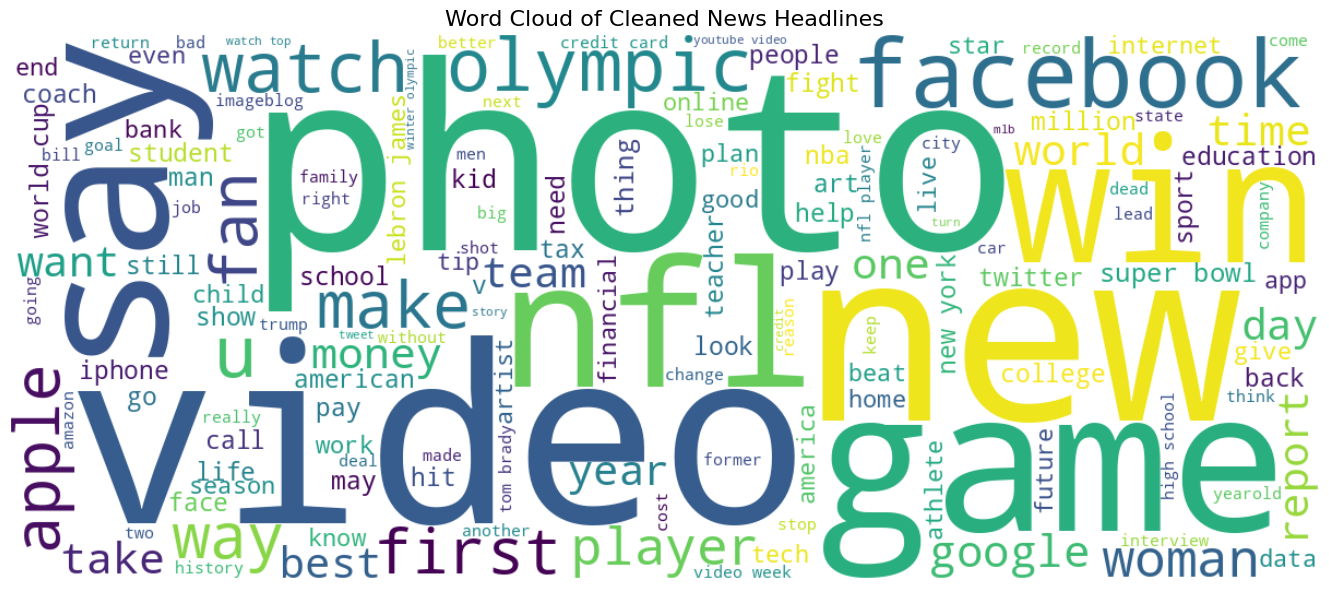

In [25]:
corpus_text = ' '.join(news_df['cleaned_headline'].values)

wc_all = WordCloud(
    width=1200, height=500, background_color='white',
    max_words=150, colormap='viridis'
).generate(corpus_text)

plt.figure(figsize=(15, 6))
plt.imshow(wc_all, interpolation='bilinear')
plt.axis('off')
plt.title('Word Cloud of Cleaned News Headlines', fontsize=16)
plt.tight_layout()
plt.show()

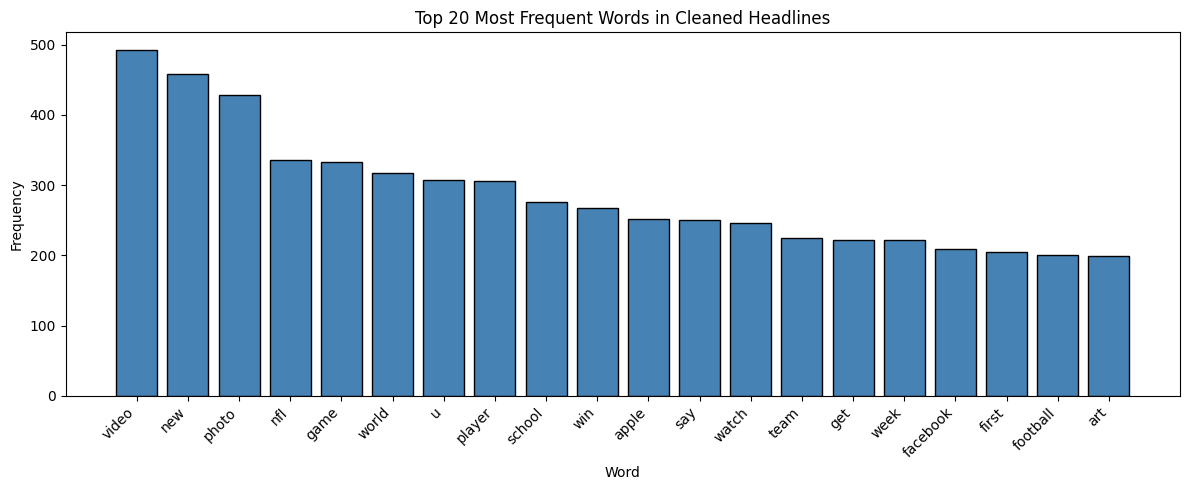

In [26]:
token_list = corpus_text.split()
token_freq = Counter(token_list)
top_tokens = token_freq.most_common(20)
top_words, top_counts = zip(*top_tokens)

plt.figure(figsize=(12, 5))
plt.bar(top_words, top_counts, color='steelblue', edgecolor='black')
plt.xticks(rotation=45, ha='right')
plt.title('Top 20 Most Frequent Words in Cleaned Headlines')
plt.xlabel('Word')
plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

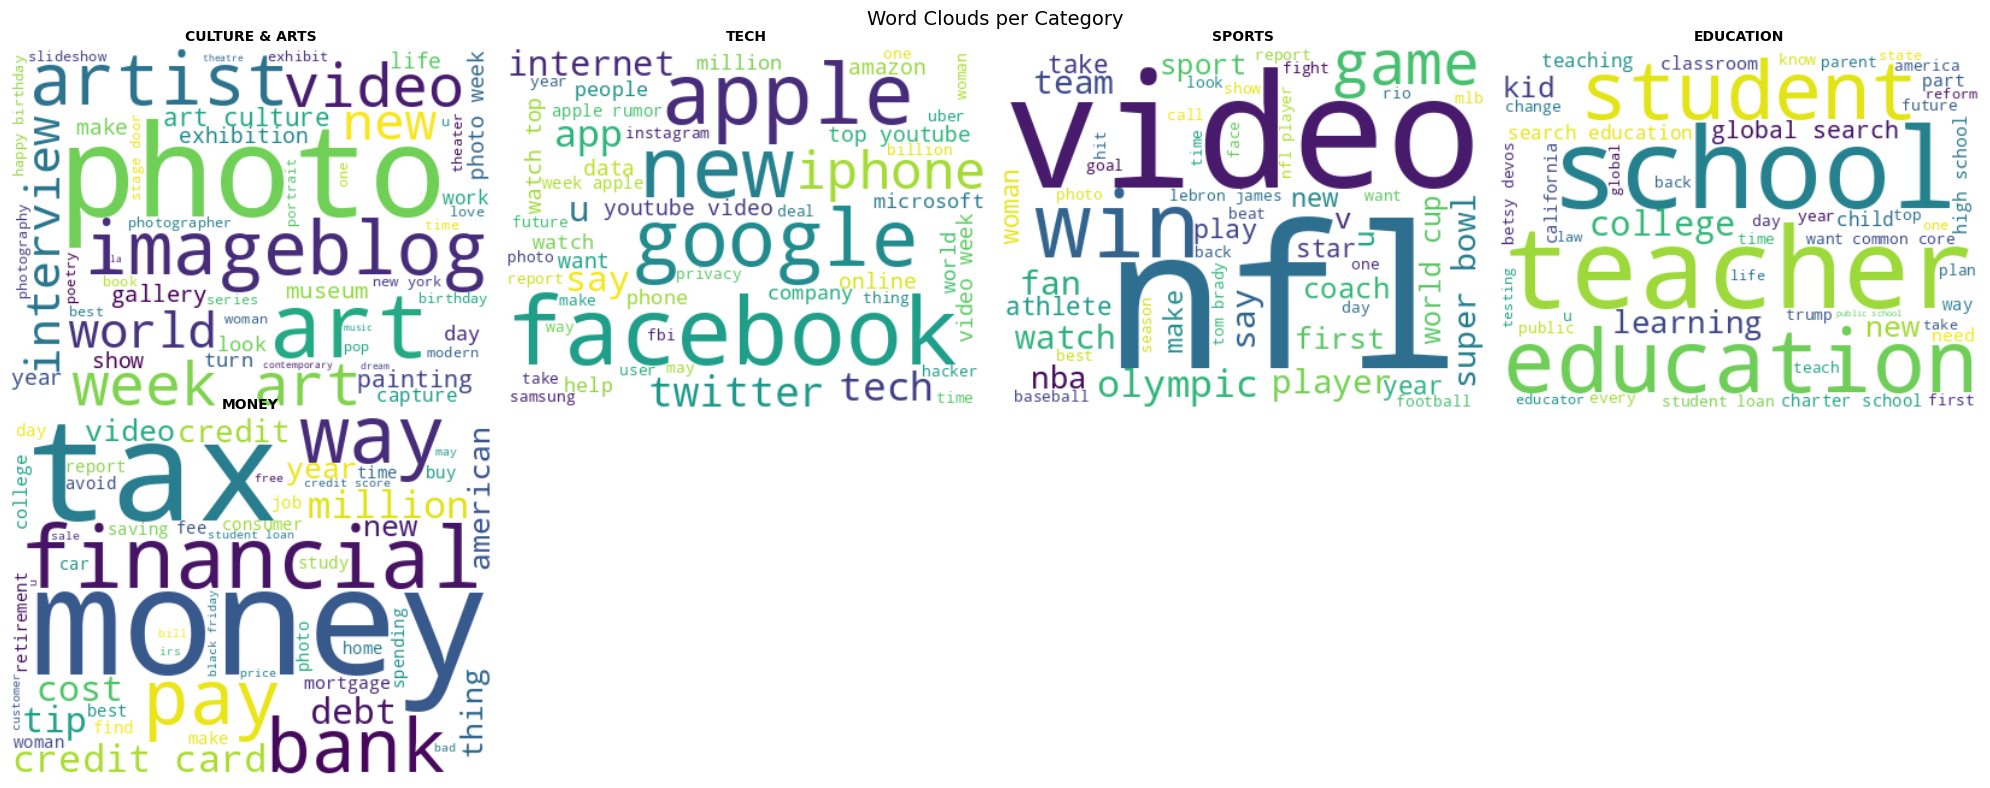

In [27]:
unique_labels = news_df['category'].unique()
num_labels = len(unique_labels)
grid_cols = min(num_labels, 4)
grid_rows = (num_labels + grid_cols - 1) // grid_cols
fig, axes = plt.subplots(grid_rows, grid_cols, figsize=(5 * grid_cols, 4 * grid_rows))
axes = np.array(axes).flatten()

for ax, lbl in zip(axes, unique_labels):
    lbl_text = ' '.join(news_df[news_df['category'] == lbl]['cleaned_headline'].values)
    wc_cat = WordCloud(width=400, height=300, background_color='white', max_words=50).generate(lbl_text)
    ax.imshow(wc_cat, interpolation='bilinear')
    ax.set_title(lbl, fontsize=10, fontweight='bold')
    ax.axis('off')

for ax in axes[num_labels:]:
    ax.axis('off')

plt.suptitle('Word Clouds per Category', fontsize=14)
plt.tight_layout()
plt.show()

## Encoding Category Labels

In [28]:
label_enc = LabelEncoder()
news_df['label'] = label_enc.fit_transform(news_df['category'])

num_classes = len(label_enc.classes_)
class_names = label_enc.classes_

print(f'Total categories: {num_classes}')
print('\nLabel-to-class mapping:')
for idx, cls in enumerate(class_names):
    print(f'  {idx}: {cls}')

Total categories: 5

Label-to-class mapping:
  0: CULTURE & ARTS
  1: EDUCATION
  2: MONEY
  3: SPORTS
  4: TECH


## Tokenization and Sequence Padding

In [29]:
headlines = news_df['cleaned_headline'].values
targets   = news_df['label'].values

X_train, X_test, y_train, y_test = train_test_split(
    headlines, targets, test_size=0.2, random_state=42, stratify=targets
)

print(f'Train set size : {len(X_train):,}')
print(f'Test set size  : {len(X_test):,}')

Train set size : 8,820
Test set size  : 2,205


In [30]:
VOCAB_SIZE = 10000

text_tokenizer = Tokenizer(num_words=VOCAB_SIZE, oov_token='<OOV>')
text_tokenizer.fit_on_texts(X_train)

train_seqs = text_tokenizer.texts_to_sequences(X_train)
test_seqs  = text_tokenizer.texts_to_sequences(X_test)

print(f'Unique tokens in vocab : {len(text_tokenizer.word_index):,}')
print(f'\nExample headline  : {X_train[0]}')
print(f'Integer-encoded   : {train_seqs[0]}')

Unique tokens in vocab : 12,036

Example headline  : need know apple fbi showdown dc
Integer-encoded   : [63, 66, 12, 366, 2124, 775]


Token Sequence Length Statistics:
  Minimum  : 1
  Mean     : 6.9
  Median   : 7.0
  95th pct : 11  <- chosen as MAX_LEN
  Maximum  : 18


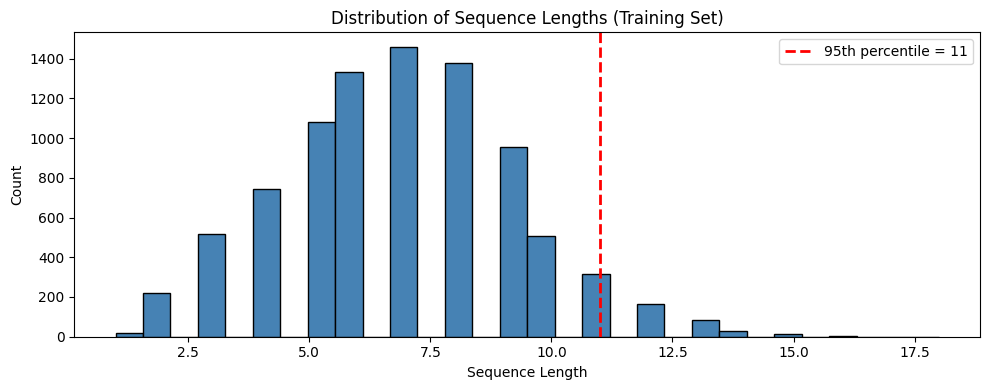

In [31]:
seq_lens = [len(s) for s in train_seqs]
MAX_LEN = int(np.percentile(seq_lens, 95))

print('Token Sequence Length Statistics:')
print(f'  Minimum  : {min(seq_lens)}')
print(f'  Mean     : {np.mean(seq_lens):.1f}')
print(f'  Median   : {np.median(seq_lens):.1f}')
print(f'  95th pct : {MAX_LEN}  <- chosen as MAX_LEN')
print(f'  Maximum  : {max(seq_lens)}')

plt.figure(figsize=(10, 4))
plt.hist(seq_lens, bins=30, edgecolor='black', color='steelblue')
plt.axvline(MAX_LEN, color='red', linestyle='--', linewidth=2,
            label=f'95th percentile = {MAX_LEN}')
plt.title('Distribution of Sequence Lengths (Training Set)')
plt.xlabel('Sequence Length')
plt.ylabel('Count')
plt.legend()
plt.tight_layout()
plt.show()

In [32]:
padded_train = pad_sequences(train_seqs, maxlen=MAX_LEN, padding='post', truncating='post')
padded_test  = pad_sequences(test_seqs,  maxlen=MAX_LEN, padding='post', truncating='post')

print(f'Padded train shape : {padded_train.shape}')
print(f'Padded test shape  : {padded_test.shape}')
print(f'\nFirst padded sequence: {padded_train[0]}')

Padded train shape : (8820, 11)
Padded test shape  : (2205, 11)

First padded sequence: [  63   66   12  366 2124  775    0    0    0    0    0]


# Part 2 - Model Architecture Design

Three architectures will be built and compared:
1. Architecture A - SimpleRNN with a trainable Embedding layer
2. Architecture B - Bidirectional LSTM with a trainable Embedding layer
3. Architecture C - Bidirectional LSTM using pretrained Word2Vec embeddings (weights frozen)

In [33]:
EMBED_DIM = 128   # set to 128 for richer word-vector representations

## Architecture A - SimpleRNN

In [34]:
srnn_net = Sequential(name='SimpleRNN_Model')
srnn_net.add(Embedding(input_dim=VOCAB_SIZE, output_dim=EMBED_DIM, input_length=MAX_LEN))
srnn_net.add(SimpleRNN(128, return_sequences=True, recurrent_dropout=0.2))
srnn_net.add(Dropout(0.3))
srnn_net.add(SimpleRNN(64, return_sequences=False))
srnn_net.add(Dropout(0.3))
srnn_net.add(Dense(128, activation='relu'))
srnn_net.add(BatchNormalization())
srnn_net.add(Dropout(0.3))
srnn_net.add(Dense(num_classes, activation='softmax'))

srnn_net.summary()

Model: "SimpleRNN_Model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn (SimpleRNN)          │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn_1 (SimpleRNN)        │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ ?                      │   0 (unbuilt) │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

## Architecture B - Bidirectional LSTM

In [35]:
bilstm_net = Sequential(name='LSTM_Model')
bilstm_net.add(Embedding(input_dim=VOCAB_SIZE, output_dim=EMBED_DIM, input_length=MAX_LEN))
bilstm_net.add(Bidirectional(LSTM(128, return_sequences=True, recurrent_dropout=0.2)))
bilstm_net.add(Dropout(0.3))
bilstm_net.add(Bidirectional(LSTM(64, return_sequences=False, recurrent_dropout=0.2)))
bilstm_net.add(Dropout(0.3))
bilstm_net.add(Dense(128, activation='relu'))
bilstm_net.add(BatchNormalization())
bilstm_net.add(Dropout(0.3))
bilstm_net.add(Dense(num_classes, activation='softmax'))

bilstm_net.summary()

Model: "LSTM_Model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_1 (Bidirectional) │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ ?                      │   0 (unbuilt) │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

## Architecture C - Bidirectional LSTM with Pretrained Word2Vec (frozen)

In [36]:
split_corpus = [text.split() for text in X_train]

w2v_embedder = Word2Vec(
    sentences=split_corpus,
    vector_size=EMBED_DIM,   # must match EMBED_DIM
    window=7,                # wider context window
    min_count=1,
    workers=4,
    epochs=30,               # more training passes
    sg=1                     # skip-gram: better for rare words
)

print(f'Word2Vec vocabulary size: {len(w2v_embedder.wv):,}')
print(f'Embedding dimension     : {w2v_embedder.wv.vector_size}')

Word2Vec vocabulary size: 12,035
Embedding dimension     : 128


In [37]:
vocab_index = text_tokenizer.word_index
embed_matrix = np.zeros((VOCAB_SIZE, EMBED_DIM))

num_hits, num_misses = 0, 0
for token, tok_idx in vocab_index.items():
    if tok_idx >= VOCAB_SIZE:
        continue
    if token in w2v_embedder.wv:
        embed_matrix[tok_idx] = w2v_embedder.wv[token]
        num_hits += 1
    else:
        num_misses += 1

print(f'Embedding matrix shape : {embed_matrix.shape}')
print(f'Tokens matched         : {num_hits:,} ({num_hits / (num_hits + num_misses + 1e-9):.1%})')
print(f'Tokens not found       : {num_misses:,}')

Embedding matrix shape : (10000, 128)
Tokens matched         : 9,998 (100.0%)
Tokens not found       : 1


In [38]:
bilstm_w2v_net = Sequential(name='LSTM_Word2Vec_Model')
bilstm_w2v_net.add(
    Embedding(
        input_dim=VOCAB_SIZE,
        output_dim=EMBED_DIM,
        input_length=MAX_LEN,
        weights=[embed_matrix],
        trainable=False
    )
)
bilstm_w2v_net.add(Bidirectional(LSTM(128, return_sequences=True, recurrent_dropout=0.2)))
bilstm_w2v_net.add(Dropout(0.3))
bilstm_w2v_net.add(Bidirectional(LSTM(64, return_sequences=False, recurrent_dropout=0.2)))
bilstm_w2v_net.add(Dropout(0.3))
bilstm_w2v_net.add(Dense(128, activation='relu'))
bilstm_w2v_net.add(BatchNormalization())
bilstm_w2v_net.add(Dropout(0.3))
bilstm_w2v_net.add(Dense(num_classes, activation='softmax'))

bilstm_w2v_net.summary()

Model: "LSTM_Word2Vec_Model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_2 (Embedding)         │ ?                      │     1,280,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_2 (Bidirectional) │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_3 (Bidirectional) │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ ?                      │   0 (unbuilt) │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,280,000 (4.88 MB)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 1,280,000 (4.88 MB)

# Part 3 - Model Training and Evaluation

In [39]:
os.makedirs('models', exist_ok=True)
os.makedirs('history', exist_ok=True)

# compute class weights to address class imbalance
balanced_weights_arr = compute_class_weight('balanced', classes=np.unique(y_train), y=y_train)
balanced_weight_dict = dict(enumerate(balanced_weights_arr))
print('Per-class weights:', {label_enc.classes_[k]: f'{v:.3f}' for k, v in balanced_weight_dict.items()})

training_logs = {}

arch_registry = {
    'Simple RNN':      srnn_net,
    'LSTM':            bilstm_net,
    'LSTM + Word2Vec': bilstm_w2v_net,
}

for arch_name, net in arch_registry.items():
    safe_name = arch_name.lower().replace(' ', '_').replace('+', 'plus').replace('2', 'two')

    cb_early = EarlyStopping(monitor='val_loss', patience=6, restore_best_weights=True)
    cb_ckpt  = ModelCheckpoint(
        f'models/{safe_name}_best.keras',
        monitor='val_accuracy', save_best_only=True, verbose=0
    )
    cb_lr    = ReduceLROnPlateau(
        monitor='val_loss', factor=0.5, patience=3, min_lr=1e-6, verbose=1
    )

    print(f"\n{'='*50}\n  Training: {arch_name}\n{'='*50}")
    net.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )

    t_start = time.time()
    run_hist = net.fit(
        padded_train, y_train,
        validation_split=0.1,
        epochs=30,
        batch_size=64,
        class_weight=balanced_weight_dict,
        callbacks=[cb_early, cb_ckpt, cb_lr],
        verbose=1
    )
    t_elapsed = time.time() - t_start
    print(f'Time: {t_elapsed:.0f}s  |  Epochs run: {len(run_hist.history["loss"])}/30')

    training_logs[arch_name] = run_hist.history
    net.save(f'models/{safe_name}.keras')
    with open(f'history/{safe_name}_history.json', 'w') as fp:
        json.dump(run_hist.history, fp)

print('\nAll architectures trained and saved to disk.')

Per-class weights: {'CULTURE & ARTS': '2.054', 'EDUCATION': '2.175', 'MONEY': '1.256', 'SPORTS': '0.434', 'TECH': '1.048'}

  Training: Simple RNN
Epoch 1/30
125/125 ━━━━━━━━━━━━━━━━━━━━ 15s 59ms/step - accuracy: 0.2644 - loss: 1.9880 - val_accuracy: 0.5283 - val_loss: 1.3517 - learning_rate: 0.0010
Epoch 2/30
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.4913 - loss: 1.4058 - val_accuracy: 0.7029 - val_loss: 0.8486 - learning_rate: 0.0010
Epoch 3/30
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.6890 - loss: 0.9471 - val_accuracy: 0.7392 - val_loss: 0.7911 - learning_rate: 0.0010
Epoch 4/30
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.8377 - loss: 0.5420 - val_accuracy: 0.7426 - val_loss: 0.8680 - learning_rate: 0.0010
Epoch 5/30
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.8918 - loss: 0.3897 - val_accuracy: 0.7948 - val_loss: 0.8353 - learning_rate: 0.0010
Epoch 6/30
115/125 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9318 - loss: 0.2574
Epoch

## Training Curves — Accuracy and Loss

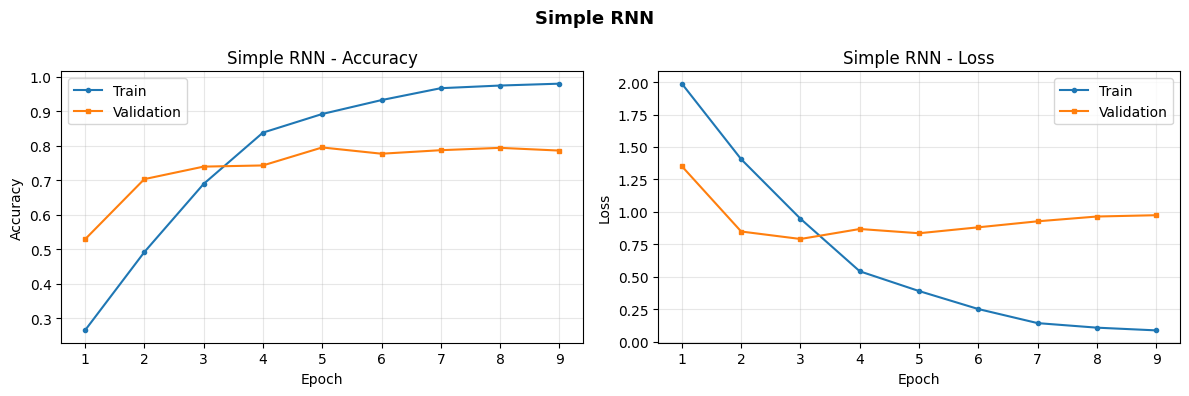

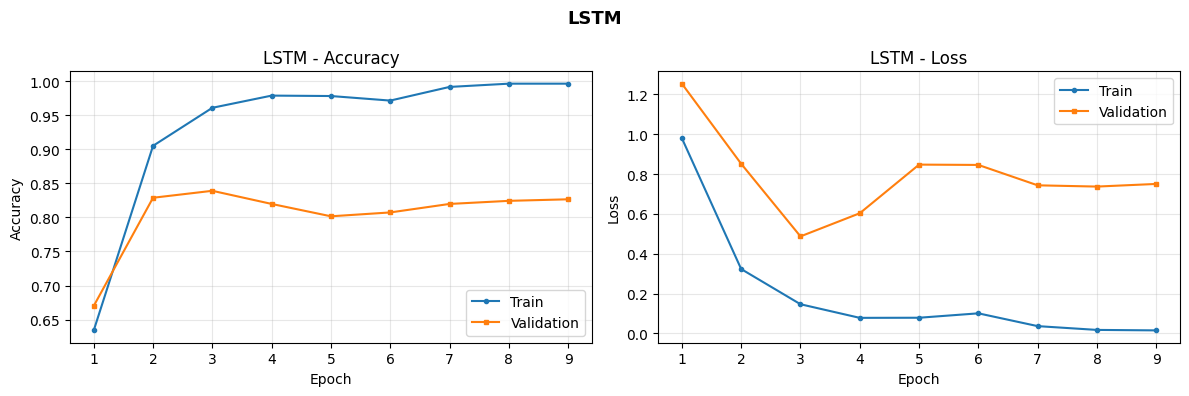

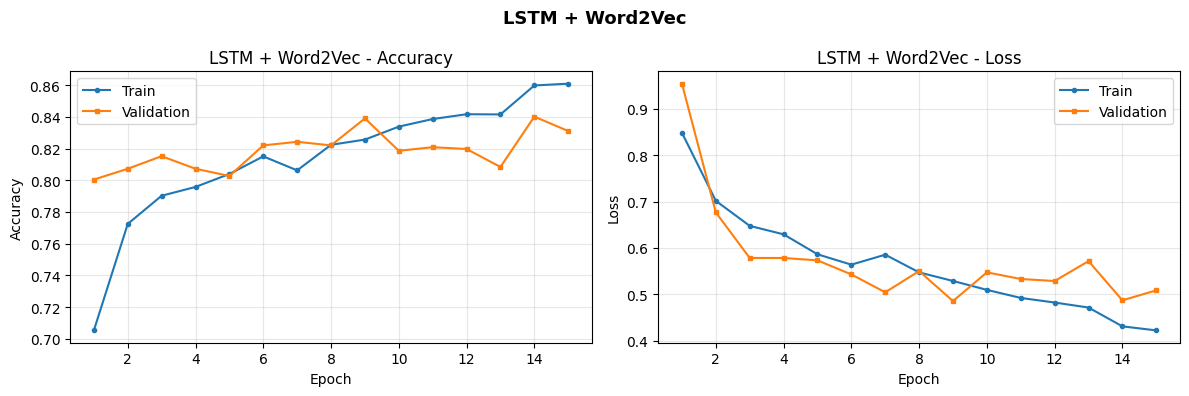

In [40]:
for arch_name, run_log in training_logs.items():
    ep_range = range(1, len(run_log['accuracy']) + 1)
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

    ax1.plot(ep_range, run_log['accuracy'],     label='Train',      marker='o', markersize=3)
    ax1.plot(ep_range, run_log['val_accuracy'], label='Validation', marker='s', markersize=3)
    ax1.set_title(f'{arch_name} - Accuracy')
    ax1.set_xlabel('Epoch'); ax1.set_ylabel('Accuracy'); ax1.legend()
    ax1.grid(True, alpha=0.3)

    ax2.plot(ep_range, run_log['loss'],     label='Train',      marker='o', markersize=3)
    ax2.plot(ep_range, run_log['val_loss'], label='Validation', marker='s', markersize=3)
    ax2.set_title(f'{arch_name} - Loss')
    ax2.set_xlabel('Epoch'); ax2.set_ylabel('Loss'); ax2.legend()
    ax2.grid(True, alpha=0.3)

    plt.suptitle(arch_name, fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.show()

## Cross-Architecture Comparison

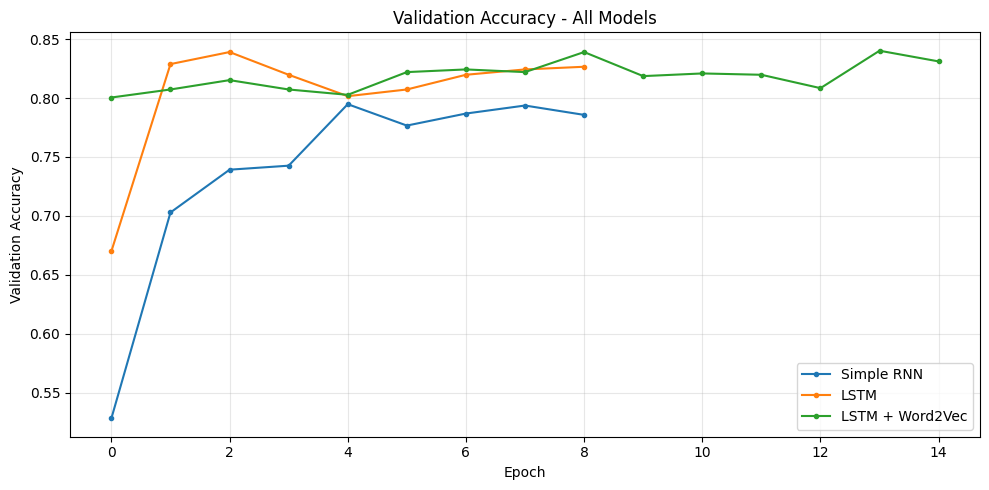

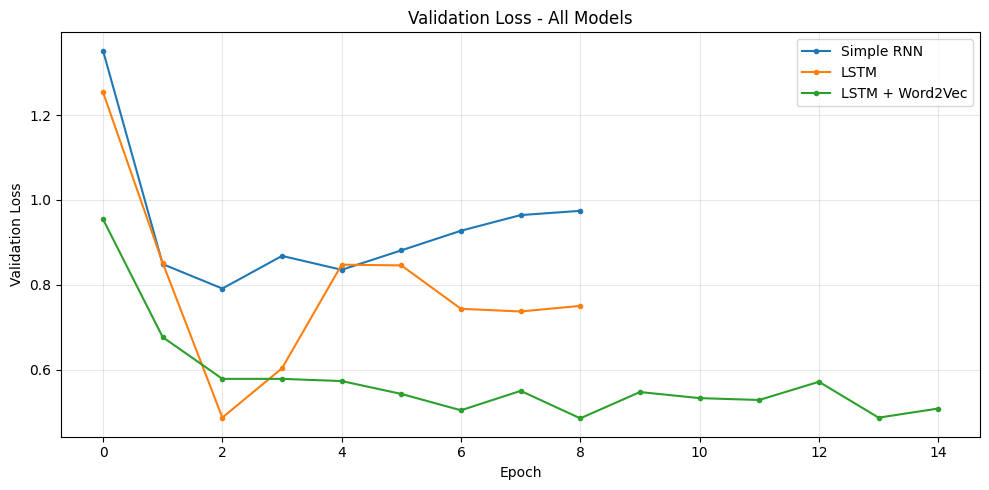


Model                 Best Val Acc  Best Val Loss   Epochs
---------------------------------------------------------
Simple RNN                 79.48%         0.7911        9
LSTM                       83.90%         0.4869        9
LSTM + Word2Vec            84.01%         0.4851       15


In [41]:
plt.figure(figsize=(10, 5))
for arch_name, run_log in training_logs.items():
    plt.plot(run_log['val_accuracy'], label=arch_name, marker='o', markersize=3)
plt.title('Validation Accuracy - All Models')
plt.xlabel('Epoch')
plt.ylabel('Validation Accuracy')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 5))
for arch_name, run_log in training_logs.items():
    plt.plot(run_log['val_loss'], label=arch_name, marker='o', markersize=3)
plt.title('Validation Loss - All Models')
plt.xlabel('Epoch')
plt.ylabel('Validation Loss')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"\n{'Model':<20} {'Best Val Acc':>13} {'Best Val Loss':>14} {'Epochs':>8}")
print('-' * 57)
for arch_name, run_log in training_logs.items():
    print(
        f"{arch_name:<20}"
        f" {max(run_log['val_accuracy']):>12.2%}"
        f" {min(run_log['val_loss']):>14.4f}"
        f" {len(run_log['loss']):>8}"
    )

## Evaluation on Held-Out Test Set


  Simple RNN
  Test Accuracy: 0.7179 (71.79%)

                precision    recall  f1-score   support

CULTURE & ARTS       0.38      0.80      0.52       215
     EDUCATION       0.48      0.63      0.55       203
         MONEY       0.83      0.41      0.55       351
        SPORTS       0.92      0.82      0.87      1015
          TECH       0.74      0.73      0.73       421

      accuracy                           0.72      2205
     macro avg       0.67      0.68      0.64      2205
  weighted avg       0.78      0.72      0.73      2205



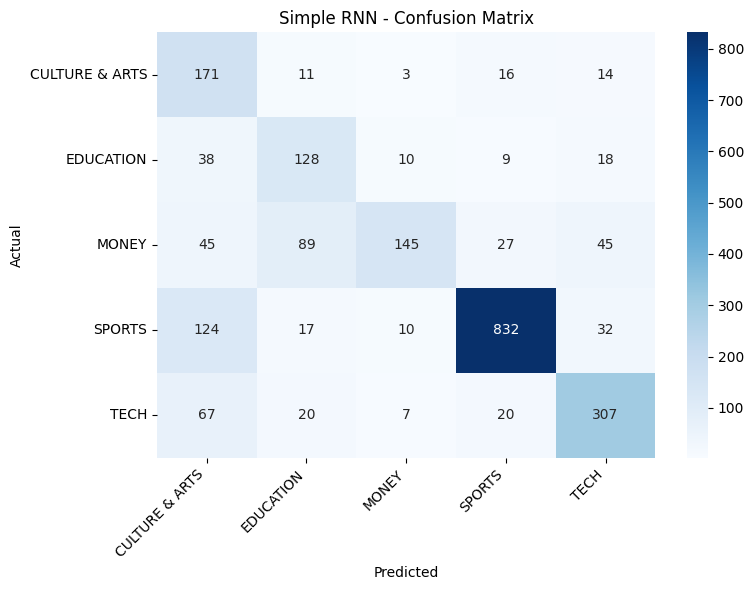


  LSTM
  Test Accuracy: 0.8259 (82.59%)

                precision    recall  f1-score   support

CULTURE & ARTS       0.66      0.80      0.72       215
     EDUCATION       0.74      0.65      0.69       203
         MONEY       0.89      0.66      0.76       351
        SPORTS       0.87      0.94      0.90      1015
          TECH       0.81      0.80      0.80       421

      accuracy                           0.83      2205
     macro avg       0.79      0.77      0.77      2205
  weighted avg       0.83      0.83      0.82      2205



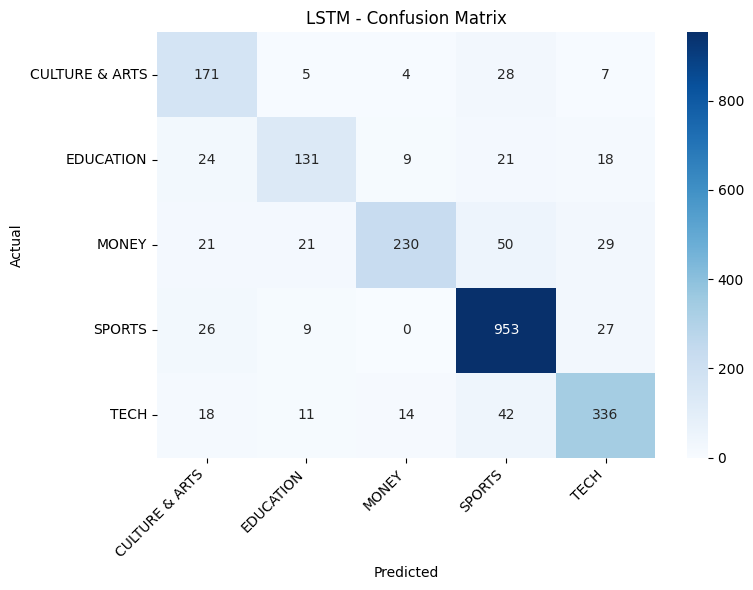


  LSTM + Word2Vec
  Test Accuracy: 0.8390 (83.90%)

                precision    recall  f1-score   support

CULTURE & ARTS       0.71      0.80      0.75       215
     EDUCATION       0.62      0.76      0.69       203
         MONEY       0.83      0.73      0.77       351
        SPORTS       0.93      0.92      0.93      1015
          TECH       0.83      0.79      0.81       421

      accuracy                           0.84      2205
     macro avg       0.78      0.80      0.79      2205
  weighted avg       0.85      0.84      0.84      2205



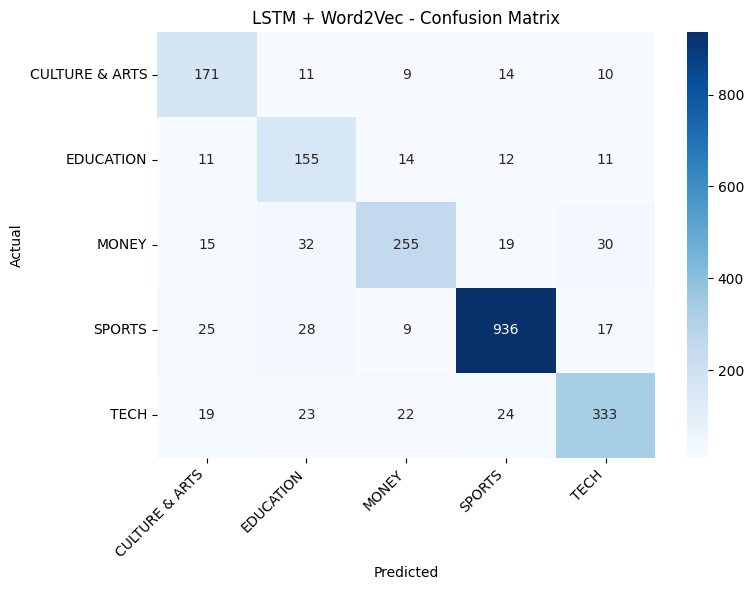

In [42]:
test_arch_map = {
    'Simple RNN':      srnn_net,
    'LSTM':            bilstm_net,
    'LSTM + Word2Vec': bilstm_w2v_net,
}

for arch_name, net in test_arch_map.items():
    y_pred = np.argmax(net.predict(padded_test, verbose=0), axis=1)
    acc    = accuracy_score(y_test, y_pred)

    print(f"\n{'='*60}")
    print(f'  {arch_name}')
    print(f"{'='*60}")
    print(f'  Test Accuracy: {acc:.4f} ({acc:.2%})')
    print()
    print(classification_report(y_test, y_pred, target_names=class_names))

    conf_mat = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(8, 6))
    sns.heatmap(
        conf_mat, annot=True, fmt='d', cmap='Blues',
        xticklabels=class_names, yticklabels=class_names
    )
    plt.title(f'{arch_name} - Confusion Matrix')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()

# Part 4 - Error Analysis

## Inspecting Misclassified Samples

In [43]:
top_net      = bilstm_w2v_net
top_net_name = 'LSTM + Word2Vec'

y_pred_top    = np.argmax(top_net.predict(padded_test, verbose=0), axis=1)
wrong_indices = np.where(y_pred_top != y_test)[0]

print(f'Architecture    : {top_net_name}')
print(f'Total samples   : {len(y_test):,}')
print(f'Errors          : {len(wrong_indices):,}')
print(f'Accuracy        : {1 - len(wrong_indices)/len(y_test):.2%}')
print()
print('Misclassification Examples (first 3):')
print('=' * 70)

for rank, i in enumerate(wrong_indices[:3], 1):
    print(f'\nCase {rank}:')
    print(f'  Headline      : {X_test[i]}')
    print(f'  True category : {class_names[y_test[i]]}')
    print(f'  Predicted     : {class_names[y_pred_top[i]]}')
    print('-' * 70)

Architecture    : LSTM + Word2Vec
Total samples   : 2,205
Errors          : 355
Accuracy        : 83.90%

Misclassification Examples (first 3):

Case 1:
  Headline      : game boy childhood dream finally exists
  True category : TECH
  Predicted     : CULTURE & ARTS
----------------------------------------------------------------------

Case 2:
  Headline      : judicial negligence compound political negligence south carolina
  True category : EDUCATION
  Predicted     : CULTURE & ARTS
----------------------------------------------------------------------

Case 3:
  Headline      : tale autism spectrum friend amberdawn
  True category : CULTURE & ARTS
  Predicted     : EDUCATION
----------------------------------------------------------------------


## Parameter Count vs Accuracy Trade-off

          Model  Parameters  Test Accuracy  Best Val Accuracy  Epochs Trained
     Simple RNN     1334725         0.7179             0.7948               9
           LSTM     1725189         0.8259             0.8390               9
LSTM + Word2Vec     1725189         0.8390             0.8401              15


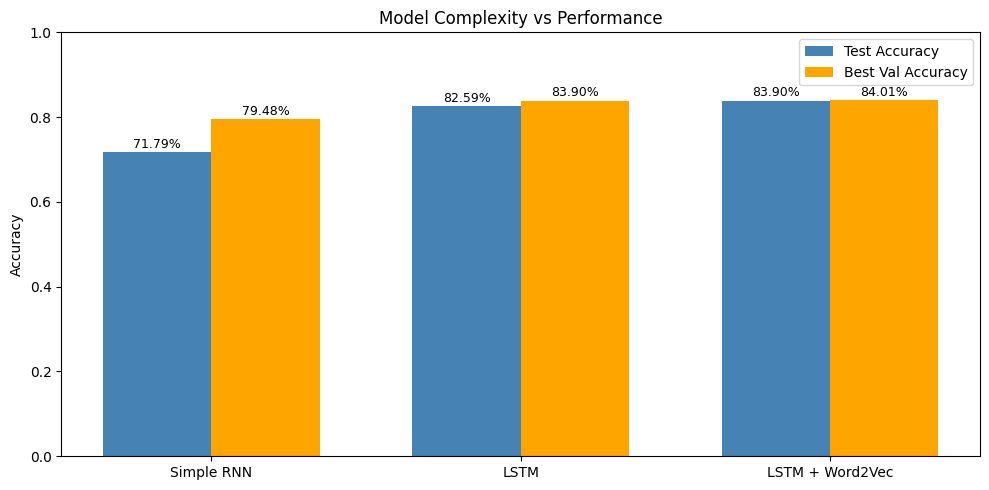

In [44]:
perf_records = []
for arch_name, net in test_arch_map.items():
    param_count = net.count_params()
    y_pred = np.argmax(net.predict(padded_test, verbose=0), axis=1)
    acc = accuracy_score(y_test, y_pred)
    perf_records.append({
        'Model': arch_name,
        'Parameters': param_count,
        'Test Accuracy': round(acc, 4),
        'Best Val Accuracy': round(max(training_logs[arch_name]['val_accuracy']), 4),
        'Epochs Trained': len(training_logs[arch_name]['loss'])
    })

perf_df = pd.DataFrame(perf_records)
print(perf_df.to_string(index=False))

fig, ax = plt.subplots(figsize=(10, 5))
bar_x = np.arange(len(perf_df))
bar_w = 0.35
grp1 = ax.bar(bar_x - bar_w/2, perf_df['Test Accuracy'],     bar_w, label='Test Accuracy',     color='steelblue')
grp2 = ax.bar(bar_x + bar_w/2, perf_df['Best Val Accuracy'], bar_w, label='Best Val Accuracy', color='orange')
ax.set_xticks(bar_x)
ax.set_xticklabels(perf_df['Model'])
ax.set_ylabel('Accuracy')
ax.set_title('Model Complexity vs Performance')
ax.legend()
ax.set_ylim(0, 1)
for bar in list(grp1) + list(grp2):
    ax.annotate(
        f'{bar.get_height():.2%}',
        xy=(bar.get_x() + bar.get_width() / 2, bar.get_height()),
        xytext=(0, 3), textcoords='offset points', ha='center', fontsize=9
    )
plt.tight_layout()
plt.show()

## Discussion of Error Patterns

**Observed failure modes:**

1. **Shared vocabulary across topics** - terms such as 'game', 'win', and 'show' surface in multiple categories, making disambiguation difficult

2. **Very short sequences** - after stopword removal, several headlines reduce to just 2-3 tokens, leaving minimal context for the model

3. **Category-neutral words** - high-frequency terms like 'new', 'report', and 'star' carry little discriminative information across classes

**Design decisions already incorporated:**

| Modification | Motivation |
|---|---|
| Stacked Bidirectional LSTM | captures context from both directions in the sequence |
| Embedding size 64 → 128 | allows denser, more expressive word representations |
| recurrent_dropout on LSTM layers | regularises recurrent connections to reduce overfitting |
| BatchNormalization after Dense | stabilises gradient flow during training |
| Balanced class weighting | prevents model bias toward majority categories |
| Word2Vec skip-gram, window=7, 30 epochs | produces stronger embeddings suited for short text |

**Potential future enhancements:**

| Idea | Expected benefit |
|---|---|
| GloVe 300d or Google News Word2Vec vectors | higher-quality pretrained embeddings vs. in-corpus W2V |
| Fine-tuning DistilBERT | contextual embeddings should lift accuracy above 90% |
| Synonym-based data augmentation | assists underrepresented category learning |
| Exclude lemmatizer for named entities | avoids corruption of proper nouns (e.g. Wills → will) |

# Part 5 - Interactive Prediction Interface

A Gradio web app to test any headline against the trained models

In [45]:
import gradio as gr


def classify_headline(input_text: str, chosen_arch: str) -> tuple:
    arch_lookup = {
        'Simple RNN':      srnn_net,
        'LSTM':            bilstm_net,
        'LSTM + Word2Vec': bilstm_w2v_net,
    }
    if not input_text.strip():
        return 'Please enter a headline.', {}

    selected_net = arch_lookup[chosen_arch]
    processed    = clean_text(input_text)
    encoded      = text_tokenizer.texts_to_sequences([processed])
    seq_padded   = pad_sequences(encoded, maxlen=MAX_LEN, padding='post', truncating='post')

    prob_scores  = selected_net.predict(seq_padded, verbose=0)[0]
    predicted_id = int(np.argmax(prob_scores))

    result_label    = f'**{class_names[predicted_id]}** ({prob_scores[predicted_id]:.1%} confidence)'
    score_breakdown = {class_names[i]: float(prob_scores[i]) for i in range(len(class_names))}
    return result_label, score_breakdown


demo_app = gr.Interface(
    fn=classify_headline,
    inputs=[
        gr.Textbox(
            label='News Headline',
            placeholder='e.g. Scientists discover new planet outside our solar system',
            lines=2
        ),
        gr.Dropdown(
            choices=['Simple RNN', 'LSTM', 'LSTM + Word2Vec'],
            label='Select Model',
            value='LSTM + Word2Vec'
        )
    ],
    outputs=[
        gr.Markdown(label='Prediction'),
        gr.Label(label='Confidence Scores', num_top_classes=num_classes)
    ],
    title='News Category Classifier',
    description='Enter any news headline to classify it using RNN or LSTM models trained on the news category dataset.',
    examples=[
        ['Scientists discover a new species of dinosaur in Argentina',  'LSTM + Word2Vec'],
        ['Apple unveils new iPhone with AI-powered camera',             'LSTM + Word2Vec'],
        ['Lakers win the NBA championship after overtime thriller',     'LSTM + Word2Vec'],
        ['School introduces AI tutoring tools for students',           'LSTM + Word2Vec'],
    ]
)

demo_app.launch(share=False, inline=True)

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
Note: opening Chrome Inspector may crash demo inside Colab notebooks.
* To create a public link, set `share=True` in `launch()`.


<IPython.core.display.Javascript object>